In [1]:
# Install any missing libraries (run this once in Colab)
!pip install wordcloud seaborn matplotlib pandas

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Plot style (optional)
sns.set(style="whitegrid")

In [10]:
# Load the survey data
# If the file is in Colab, upload it via the sidebar or files panel, then use the correct filename
file_path = r"C:\Users\hp\Downloads\archive (10)\Student_Satisfaction_Survey.csv"  # change if needed

df_survey = pd.read_csv('Student_Satisfaction_Survey.csv', encoding='Windows-1252')
df_survey.columns = [c.strip() for c in df_survey.columns]

df_survey.head()

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teacher’s approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [12]:
# Identify weightage columns
weight_cols = [c for c in df_survey.columns if c.startswith("Weightage")]

# Derive numeric rating (1–5) from which weightage column is 1
def derive_rating(row):
    for i, col in enumerate(weight_cols, start=1):
        if row[col] == 1:
            return i
    return np.nan # Corrected: Return np.nan if no weightage column is 1

if "Rating" not in df_survey.columns:
    df_survey["Rating"] = df_survey.apply(derive_rating, axis=1)

# Create simple synthetic comments based on Rating if not present
if "Comment" not in df_survey.columns:
    comment_map = {
        1: "Very dissatisfied with this event. Many issues and problems throughout.",
        2: "Not satisfied, several aspects of the course need improvement.",
        3: "Average experience, some good parts and some bad parts.",
        4: "Satisfied with the overall experience and teaching quality.",
        5: "Very happy, excellent, well organized and engaging event."
    }
    df_survey["Comment"] = df_survey["Rating"].map(comment_map)

df_survey[["Questions", "Rating", "Comment"]].head()

,Questions,Rating,Comment
0,How much of the syllabus was covered in the cl...,3.0,"Average experience, some good parts and some b..."
1,How well did the teachers prepare for the clas...,5.0,"Very happy, excellent, well organized and enga..."
2,How well were the teachers able to communicate?,5.0,"Very happy, excellent, well organized and enga..."
3,The teacher’s approach to teaching can best be...,3.0,"Average experience, some good parts and some b..."
4,Fairness of the internal evaluation process by...,4.0,Satisfied with the overall experience and teac...


/tmp/ipython-input-2215176707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=q_means.values, y=q_means.index, palette="viridis")
/tmp/ipython-input-2215176707.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


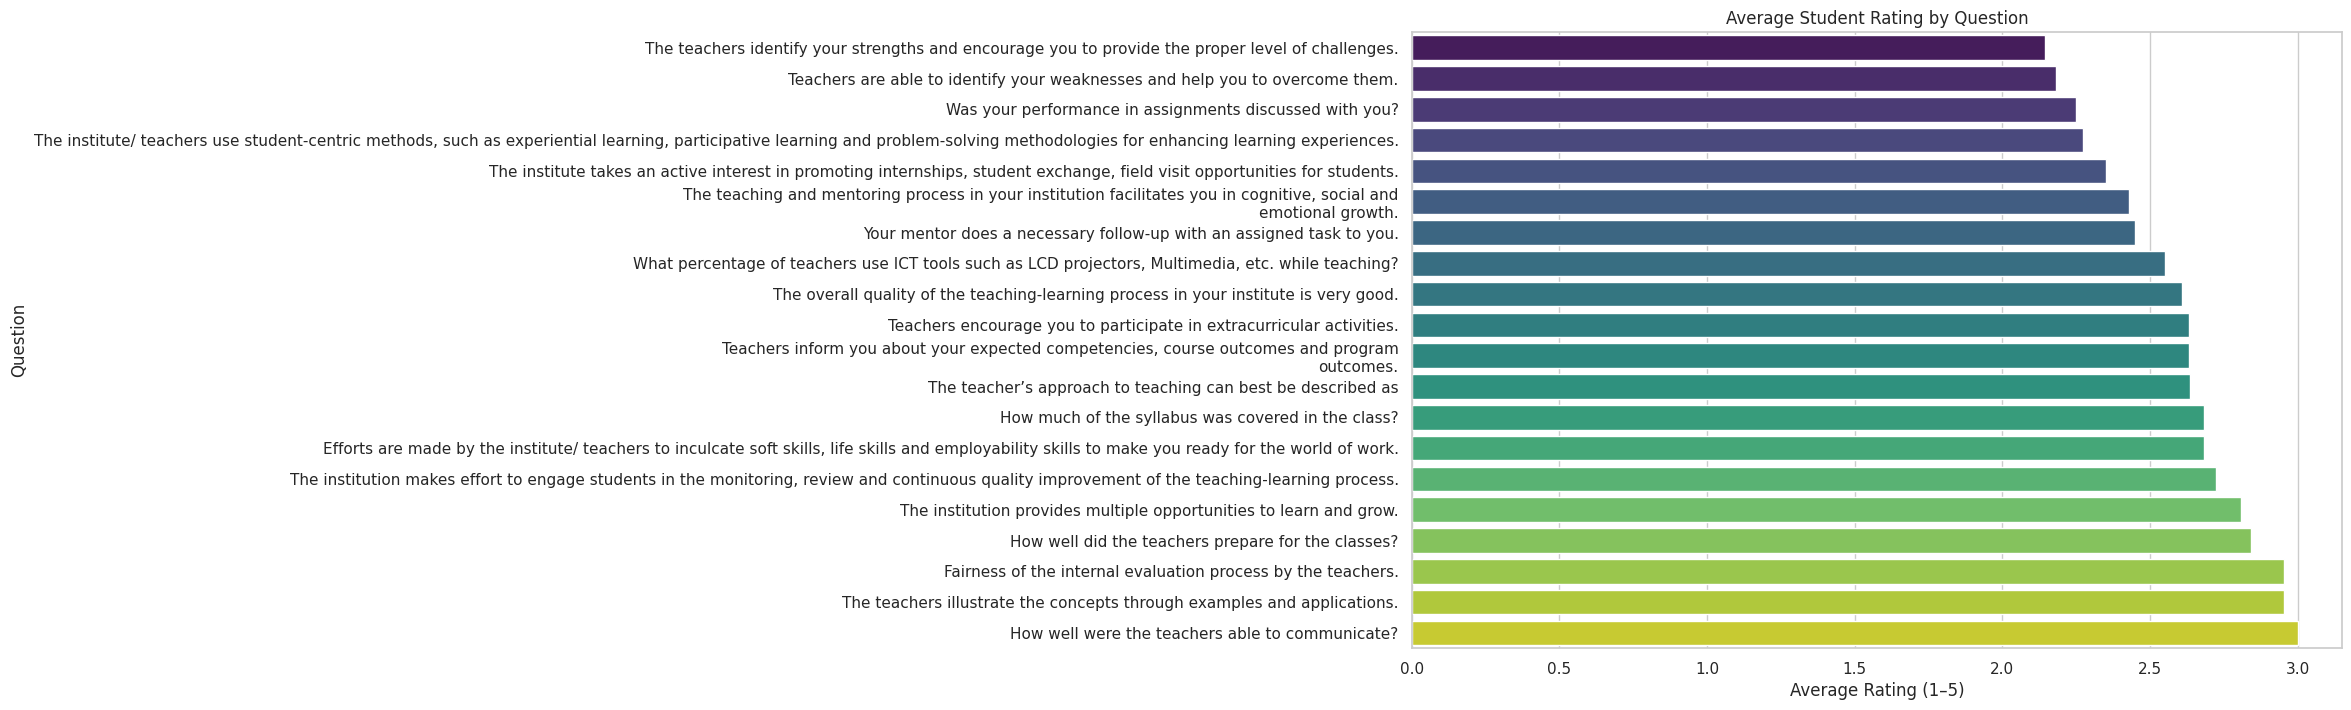

In [13]:
# Average rating by question
q_means = df_survey.groupby("Questions")["Rating"].mean().sort_values()

plt.figure(figsize=(12, 8))
sns.barplot(x=q_means.values, y=q_means.index, palette="viridis")
plt.xlabel("Average Rating (1–5)")
plt.ylabel("Question")
plt.title("Average Student Rating by Question")
plt.tight_layout()
plt.show()

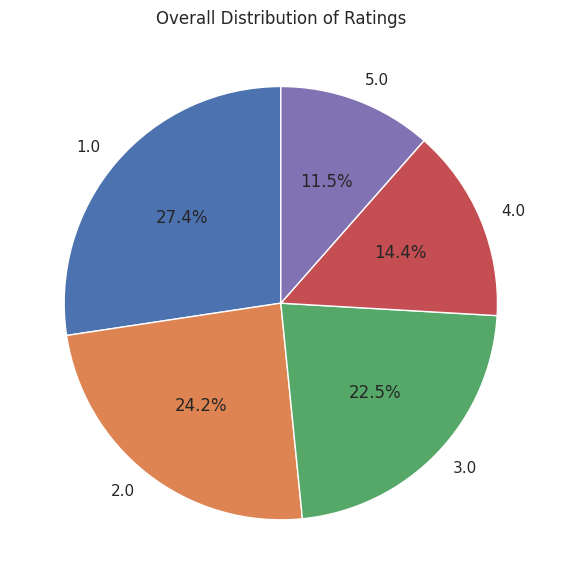

In [14]:
# Overall distribution of ratings
rating_counts = df_survey["Rating"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Overall Distribution of Ratings")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1585683482.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=course_means.values, y=course_means.index, palette="Blues_r")


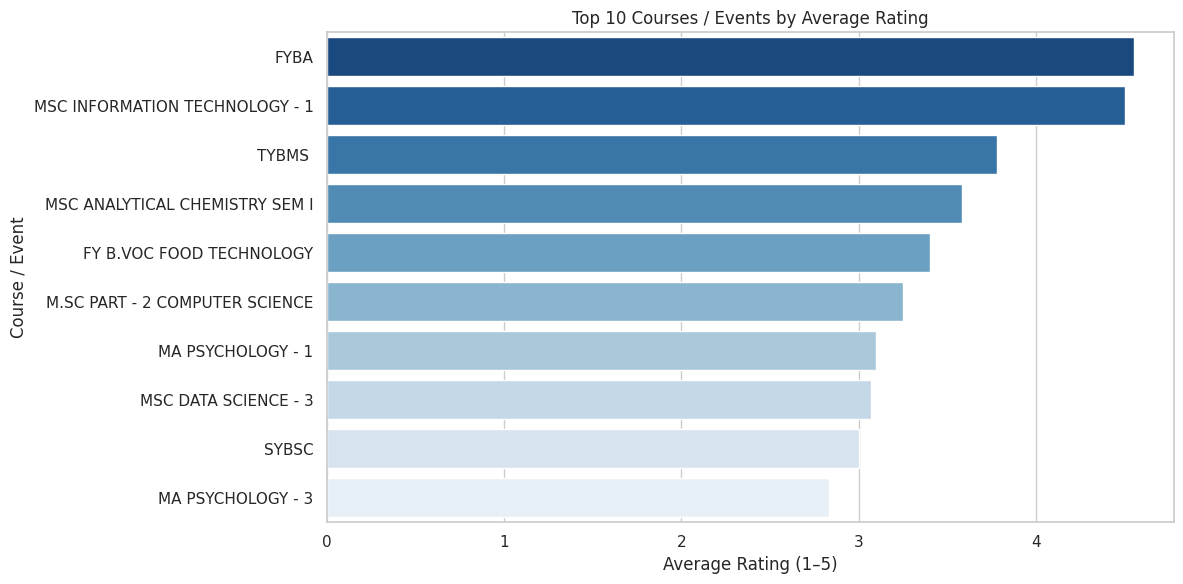

In [15]:
# Find course column name (handles slight naming differences)
course_col = None
if "Course Name" in df_survey.columns:
    course_col = "Course Name"
else:
    for c in df_survey.columns:
        if "Course Name" in c:
            course_col = c
            break

if course_col is None:
    raise ValueError("Could not find a Course Name column. Check your CSV headers.")

# Average rating by course / event
course_means = (
    df_survey
    .groupby(course_col)["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=course_means.values, y=course_means.index, palette="Blues_r")
plt.xlabel("Average Rating (1–5)")
plt.ylabel("Course / Event")
plt.title("Top 10 Courses / Events by Average Rating")
plt.tight_layout()
plt.show()

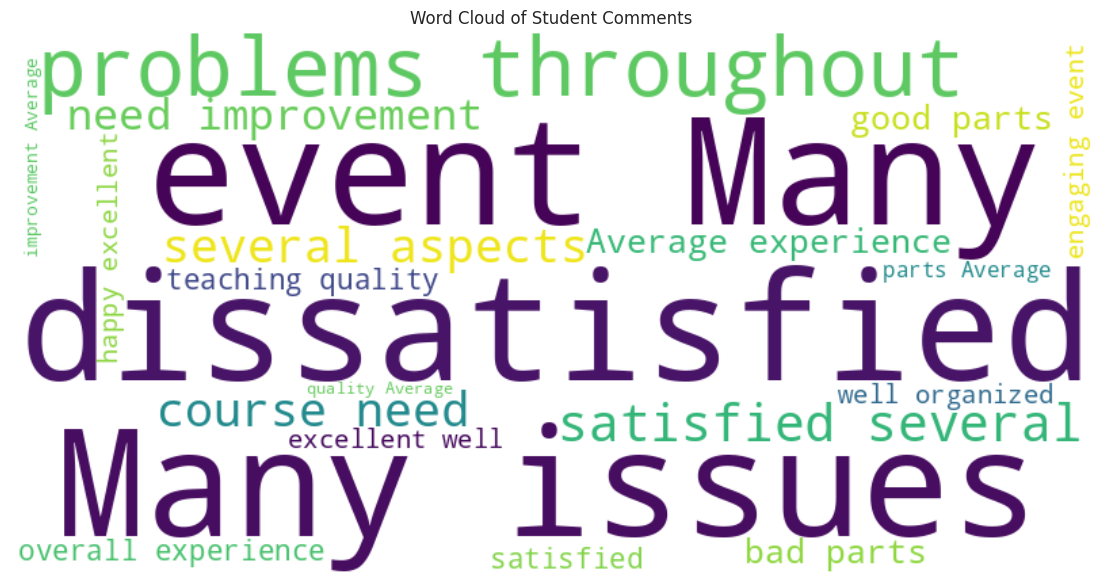

In [16]:
# Combine all comments into one big text
all_text = " ".join(df_survey["Comment"].dropna().astype(str).tolist())

# Generate word cloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Student Comments")
plt.tight_layout()
plt.show()

In [17]:
overall_mean = df_survey["Rating"].mean()
q_low = q_means.head(3)
q_high = q_means.tail(3)

print("Overall average rating:", overall_mean)
print("\nLowest-rated questions:")
print(q_low)
print("\nHighest-rated questions:")
print(q_high)

Overall average rating: 2.584352078239609

Lowest-rated questions:
Questions
The teachers identify your strengths and encourage you to provide the proper level of challenges.    2.142857
Teachers are able to identify your weaknesses and help you to overcome them.                         2.181818
Was your performance in assignments discussed with you?                                              2.250000
Name: Rating, dtype: float64

Highest-rated questions:
Questions
Fairness of the internal evaluation process by the teachers.               2.952381
The teachers illustrate the concepts through examples and applications.    2.952381
How well were the teachers able to communicate?                            3.000000
Name: Rating, dtype: float64
